# Import and Visualize Results of Molpro Calculation

This is a small script to visualize various results obtained from molpro-calculations, because im to lazy

In [174]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import re

# Reference Data 

In [191]:
trans_hcooh_gas = {
    "v1": 3570.5,
    "v2": 2942.1,
    "v3": 1776.8,
    "v4": 1379.1,
    "v5": 1306.2,
    "v6": 1104.9,
    "v7": 1033.5,
    "v8": 640.7,
    "v9": 626.2
}

trans_hcooh_vci_old = {
    "v1": 3579.0,
    "v2": 2945.3,
    "v3": 1782.3,
    "v4": 1385.1,
    "v5": 1331.9,
    "v6": 1104.6,
    "v7": 1036.2,
    "v8": 648.3,
    "v9": 626.8
}

trans_dcooh_gas = {
    "v1": 3566,
    "v2": 2220,
    "v3": 1763, 
    "v4": 1297,
    "v5": 1142,
    "v6": 972,
    "v7": 873,
    "v8": 632,
    "v9": 621,
}

trans_hcood_gas = {
    "v1": 2938.0,
    "v2": 2631.6,
    "v3": 1772.1,
    "v4": 1366.5,
    "v5": 1177.1,
    "v6": 1011.7,
    "v7": 558.3,
    "v8": 0, # missing value
    "v9": 508.1,
}

trans_dcood_gas = {
    "v1": 2632,
    "v2": 2232,
    "v3": 1760,
    "v4": 1171,
    "v5": 1042,
    "v6": 945,
    "v8": 873,
    "v7": 554,
    "v9": 492
}

# File-Readin

In [176]:
dcood_path = "/home/lme/formic_acid_dennis/monomer_calculations/dcood.out"
dcooh_path = "/home/lme/formic_acid_dennis/monomer_calculations/dcooh/dcooh.out" 
hcood_path =  "/home/lme/formic_acid_dennis/monomer_calculations/hcood/hcood.out"
hcooh_path =  "/home/lme/formic_acid_dennis/monomer_calculations/hcooh/hcooh.out"

# VCI Calculation Results

The Results of the VCI Calculation come after the Text **Results of VCI Calculation** so this is filtered this way. Further we split into:

+ Fundamentals
+ Overtones
+ Combination Bands

In [177]:
import re
import pandas as pd

def parse_multi_state_block(blocks):
    result = {}
    for block in blocks:
        state_label = block[0].split(":")[1].strip()
        result[state_label] = {}
        current_state = None
        for line in block[1:]:
            state_match = re.match(r"State\s+(\d+).*?Energy\s+\(abs/rel\):\s+([\d.]+)\s+([\d.]+).*?IR\s+Int\.\s+([\d.]+)", line)
            if state_match:
                state_num = state_match.group(1)
                abs_energy = float(state_match.group(2))
                rel_energy = float(state_match.group(3))
                ir_intensity = float(state_match.group(4))
                current_state = f"State {state_num}"
                result[state_label][current_state] = {
                    "Energy (abs)": abs_energy,
                    "Energy (rel)": rel_energy,
                    "IR Intensity": ir_intensity,
                    "Configurations": {}
                }
                continue
            config_match = re.match(r"(\d+)\.\s+([\d.]+)%\s+\(([-+]?\s*\d+\.\d+)\)\s+Configuration:\s+\|([^>]+)>.*?Overlap:\s+([\d.]+)", line)
            if config_match and current_state:
                config_num = config_match.group(1)
                percentage = float(config_match.group(2))
                coefficient = float(config_match.group(3))
                config = config_match.group(4)
                overlap = float(config_match.group(5))
                result[state_label][current_state]["Configurations"][config_num] = {
                    "Percentage": percentage,
                    "Coefficient": coefficient,
                    "Configuration": config.strip(),
                    "Overlap": overlap
                }
    return result

def parse_vci_data(ls):
    cleaned = pd.DataFrame(columns=["Mode", "E(abs)", "VCI(5)", "IR Intens", "Leading Term", "Type", "Dim", "Confs", "CPU tot.", "CPU"])
    multi_state_blocks = []
    ls = list(filter(None, ls))
    ls = ls[1:]
    for line in ls:
        parts = re.split(r'\s{2,}', line.strip())
        if len(parts) >= 10:
            cleaned.loc[len(cleaned)] = parts[:10]
        elif len(parts) <= 8:
            multi_state_blocks.append(parts)
    multi_state_blocks = [' '.join(block) for block in multi_state_blocks]
    blocks = []
    current_block = []
    for line in multi_state_blocks:
        if "Multi-state" in line:
            if current_block:
                blocks.append(current_block)
                current_block = []
            current_block.append(line)
        else:
            current_block.append(line)
    if current_block:
        blocks.append(current_block)
    result_multistate = parse_multi_state_block(blocks)
    return cleaned, result_multistate

def parse_molpro_vci_results(file_path):
    vci_block = []
    fundamentals = []
    overtones = []
    combination_bands = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
        extracting = False
    for line in lines:
        if "Results of VCI calculation" in line:
            extracting = True
        if "VCI/ZPVE" in line:
            extracting = False
        if extracting:
            vci_block.append(line.strip())
    fundamental_switch = False
    overtones_switch = False
    combination_bands_switch = False
    for line in vci_block:
        if "Fundamentals" in line:
            fundamental_switch = True
            overtones_switch = False
            combination_bands_switch = False
        elif "VCI/ZPVE" in line:
            fundamental_switch = False
            overtones_switch = False
            combination_bands_switch = False
        elif "Overtones" in line:
            fundamental_switch = False
            overtones_switch = True
            combination_bands_switch = False
        elif "Combination bands" in line:
            fundamental_switch = False
            overtones_switch = False
            combination_bands_switch = True
        elif fundamental_switch:
            fundamentals.append(line.strip())
        elif overtones_switch:
            overtones.append(line.strip())
        elif combination_bands_switch:
            combination_bands.append(line.strip())
    fundamentals_df, fundamentals_multistate = parse_vci_data(fundamentals)
    overtones_df, overtones_multistate = parse_vci_data(overtones)
    combination_bands_df, combination_bands_multistate = parse_vci_data(combination_bands)
    return {
        "fundamentals": fundamentals_df,
        "fundamentals_multistate": fundamentals_multistate,
        "overtones": overtones_df,
        "overtones_multistate": overtones_multistate,
        "combination_bands": combination_bands_df,
        "combination_bands_multistate": combination_bands_multistate
    }

In [178]:
results_hcooh = parse_molpro_vci_results(hcooh_path)
results_hcooh["fundamentals"]

,Mode,E(abs),VCI(5),IR Intens,Leading Term,Type,Dim,Confs,CPU tot.,CPU
0,9^1 A',10910.54,3567.84,34.37,0.6489,T,3987,178804,35.9,31.1
1,8^1 A',10284.07,2941.37,33.99,0.9132,T,3117,173396,48.6,12.7
2,7^1 A',9121.15,1778.45,316.76,0.9856,T,1851,153636,56.1,7.5
3,6^1 A',8726.40,1383.70,2.88,0.8932,T,2129,151643,63.1,6.9
4,5^1 A',8593.22,1250.52,14.91,0.7784,T,2656,165258,78.1,15.0
5,4^1 A',8449.45,1106.75,273.14,0.9870,T,1827,150291,86.1,8.0
6,3^1 A'',8375.51,1032.81,2.58,0.9906,T,1311,134278,90.9,4.8
7,2^1 A'',7990.78,648.09,135.21,0.9675,T,1457,132642,96.6,5.7
8,1^1 A',7969.26,626.56,38.82,0.9919,T,1501,147764,102.7,6.2


In [179]:
results_hcood = parse_molpro_vci_results(hcood_path)
results_hcood["fundamentals"]

,Mode,E(abs),VCI(5),IR Intens,Leading Term,Type,Dim,Confs,CPU tot.,CPU
0,9^1 A',9559.52,2940.36,25.21,0.8002,T,3156,176953,28.9,25.8
1,8^1 A',9252.06,2632.91,47.92,0.9703,T,1818,166908,36.7,7.8
2,7^1 A',8394.77,1775.61,289.15,0.9717,T,1646,160791,43.1,6.4
3,6^1 A',7985.28,1366.12,2.78,0.9922,T,1076,158491,47.8,4.7
4,5^1 A',7797.81,1178.66,175.85,0.9885,T,1192,157391,52.8,5.0
5,4^1 A'',7650.13,1030.97,1.01,0.9875,T,973,142284,56.7,3.9
6,3^1 A',7595.16,976.00,47.75,0.8923,T,1493,166986,63.2,6.6
7,2^1 A',7177.53,558.38,39.99,0.9931,T,1001,153680,67.7,4.5
8,1^1 A'',7126.64,507.49,83.77,0.9797,T,970,139751,71.9,4.2


In [180]:
results_dcooh = parse_molpro_vci_results(dcooh_path)
results_dcooh["fundamentals"]

,Mode,E(abs),VCI(5),IR Intens,Leading Term,Type,Dim,Confs,CPU tot.,CPU
0,9^1 A',10234.61,3570.34,68.26,0.9378,T,3608,174351,41.0,36.6
1,8^1 A',8888.41,2224.15,32.39,0.7668,T,3895,178523,109.4,68.4
2,7^1 A',8389.90,1725.64,138.04,0.6474,T,2387,170184,139.2,29.7
3,6^1 A',7904.39,1240.12,3.91,0.7720,T,2505,168439,152.6,13.4
4,5^1 A',7807.68,1143.42,214.67,0.9865,T,1778,157657,160.1,7.5
5,4^1 A',7635.08,970.81,50.20,0.9912,T,1482,156662,165.9,5.9
6,3^1 A'',7537.07,872.80,0.69,0.9920,T,1159,142221,170.1,4.2
7,2^1 A'',7303.93,639.67,130.47,0.9648,T,1351,141204,175.2,5.1
8,1^1 A',7285.09,620.83,38.78,0.9916,T,1417,154744,181.0,5.8


In [181]:
results_dcood = parse_molpro_vci_results(dcood_path)
results_dcood["fundamentals"]

,Mode,E(abs),VCI(5),IR Intens,Leading Term,Type,Dim,Confs,CPU tot.,CPU
0,9^1 A',8571.26,2633.25,42.19,0.9483,T,2204,176057,20.1,15.5
1,8^1 A',8170.10,2232.10,29.46,0.7468,T,2586,180479,47.7,27.6
2,7^1 A',7700.43,1762.42,159.05,0.7207,T,1846,179875,64.7,17.0
3,6^1 A',7110.23,1172.23,167.20,0.9906,T,1180,165889,72.2,7.6
4,5^1 A',6978.85,1040.85,9.36,0.9283,T,1522,165049,82.1,9.8
5,4^1 A',6884.89,946.88,57.13,0.9843,T,1295,170793,90.7,8.6
6,3^1 A'',6811.00,873.00,0.94,0.9934,T,939,151985,96.1,5.5
7,2^1 A',6492.67,554.67,39.97,0.9929,T,1076,162153,103.1,7.0
8,1^1 A'',6430.09,492.08,77.26,0.9773,T,1012,150167,109.5,6.4


Following Plot can be quickly be used to check for abnormal stuff in CPU time or in Configurations

In [182]:
def plot_configurations_and_runtime(results):
    # Extract 
    fundamentals = results["fundamentals"]
    overtones = results["overtones"]
    combination_bands = results["combination_bands"]
    plt.figure(figsize=(12, 10))
    # Create subplots for each category

    plt.subplot(3, 2, 1)
    plt.bar(fundamentals['Mode'], fundamentals['Confs'].astype(int), color='blue')
    plt.title('Fundamentals: Number of Configurations')
    plt.xlabel('Mode')
    plt.ylabel('Number of Configurations')
    plt.xticks(rotation=90)
    plt.subplot(3, 2, 2)
    plt.bar(fundamentals['Mode'], fundamentals['CPU tot.'].astype(float), color='blue')
    plt.title('Fundamentals: CPU Total Time')
    plt.xlabel('Mode')
    plt.ylabel('CPU Total Time (s)')
    plt.xticks(rotation=90)
    plt.subplot(3, 2, 3)
    plt.bar(overtones['Mode'], overtones['Confs'].astype(int), color='orange')
    plt.title('Overtones: Number of Configurations')
    plt.xlabel('Mode')
    plt.ylabel('Number of Configurations')
    plt.xticks(rotation=90)
    plt.subplot(3, 2, 4)    
    plt.bar(overtones['Mode'], overtones['CPU tot.'].astype(float), color='orange')
    plt.title('Overtones: CPU Total Time')
    plt.xlabel('Mode')  
    plt.ylabel('CPU Total Time (s)')
    plt.xticks(rotation=90)
    plt.subplot(3, 2, 5)
    plt.bar(combination_bands['Mode'], combination_bands['Confs'].astype(int), color='green')
    plt.title('Combination Bands: Number of Configurations')
    plt.xlabel('Mode')
    plt.ylabel('Number of Configurations')
    plt.xticks(rotation=90)
    plt.subplot(3, 2, 6)
    plt.bar(combination_bands['Mode'], combination_bands['CPU tot.'].astype(float), color='green')
    plt.title('Combination Bands: CPU Total Time')
    plt.xlabel('Mode')
    plt.ylabel('CPU Total Time (s)')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()



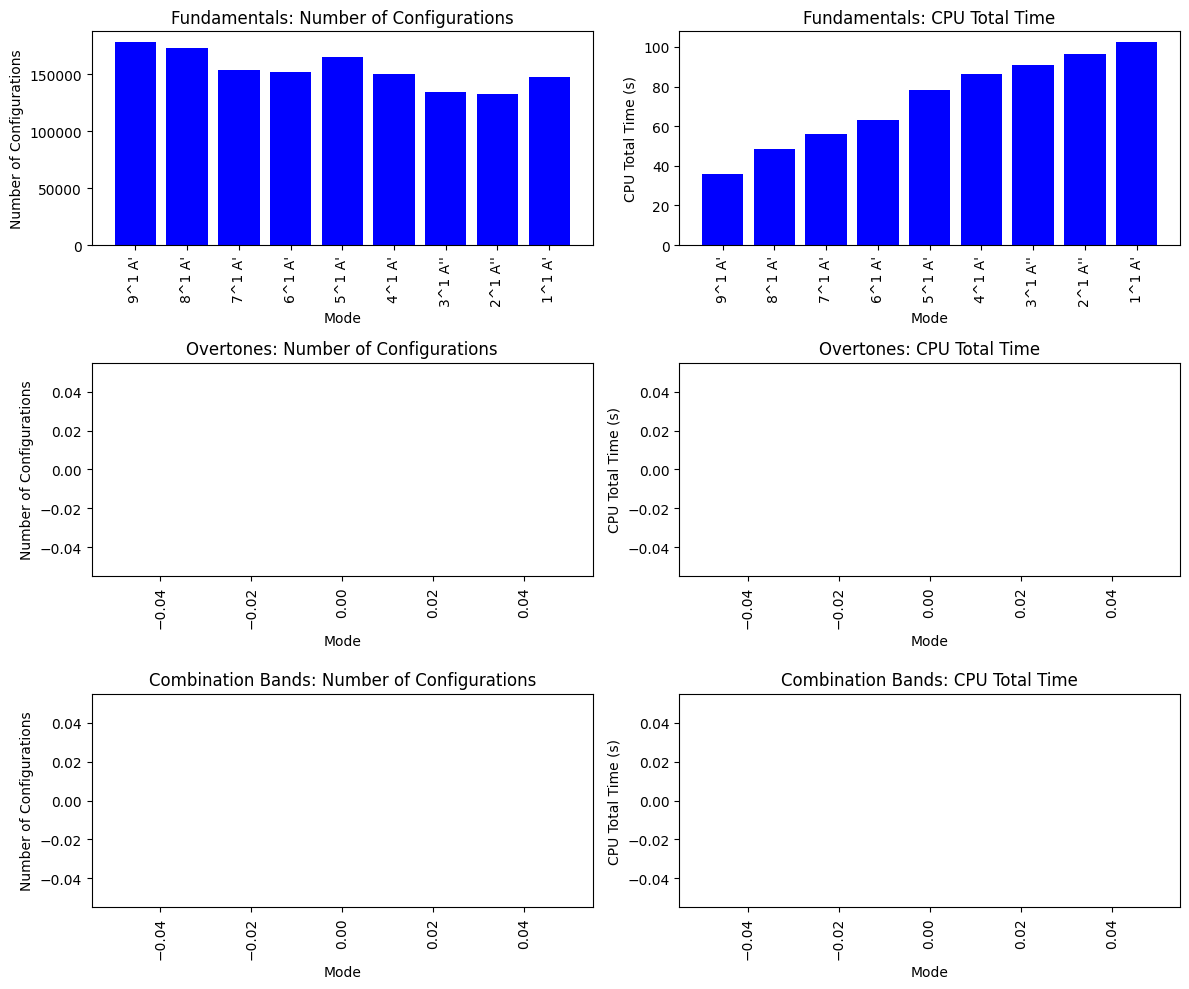

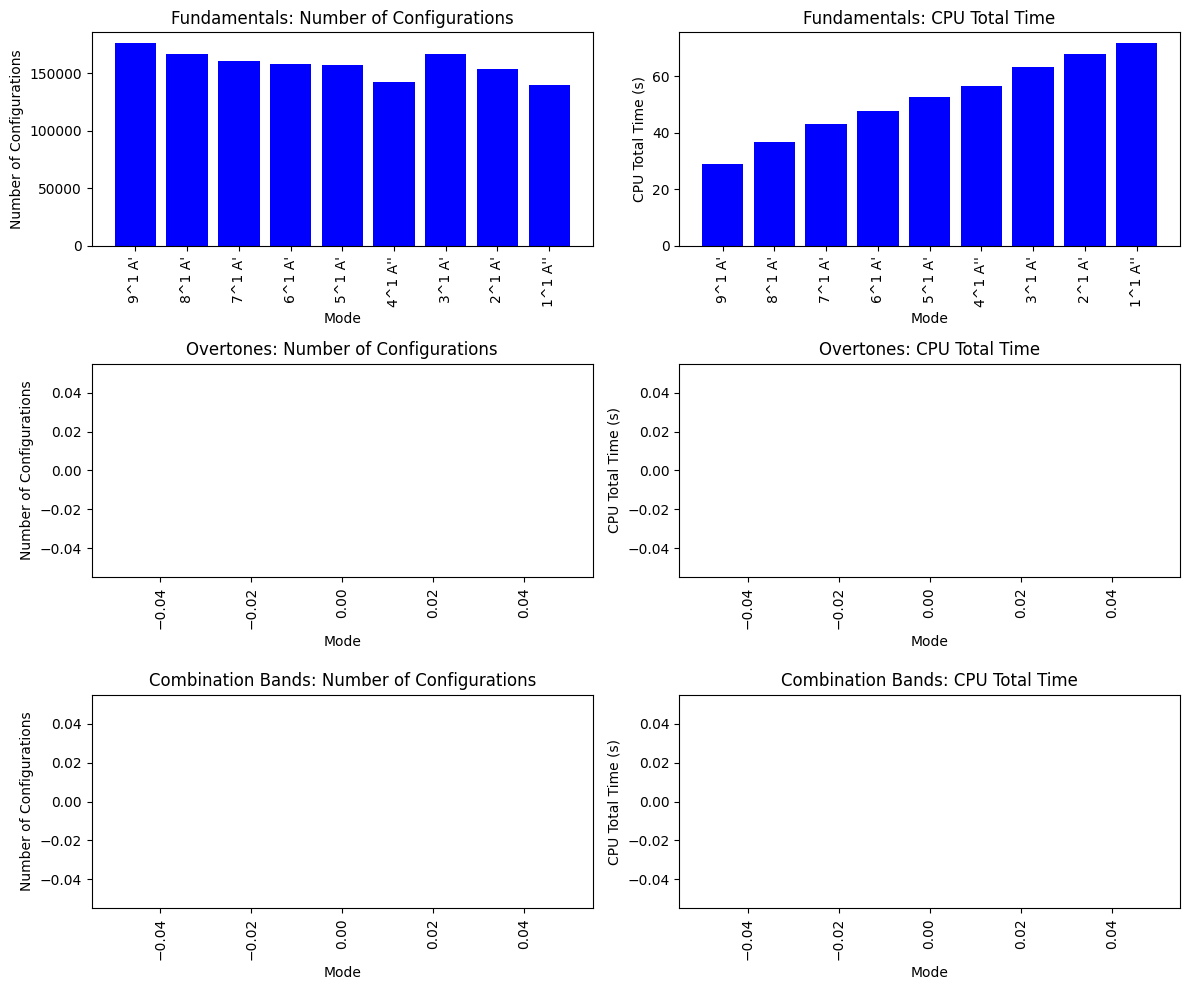

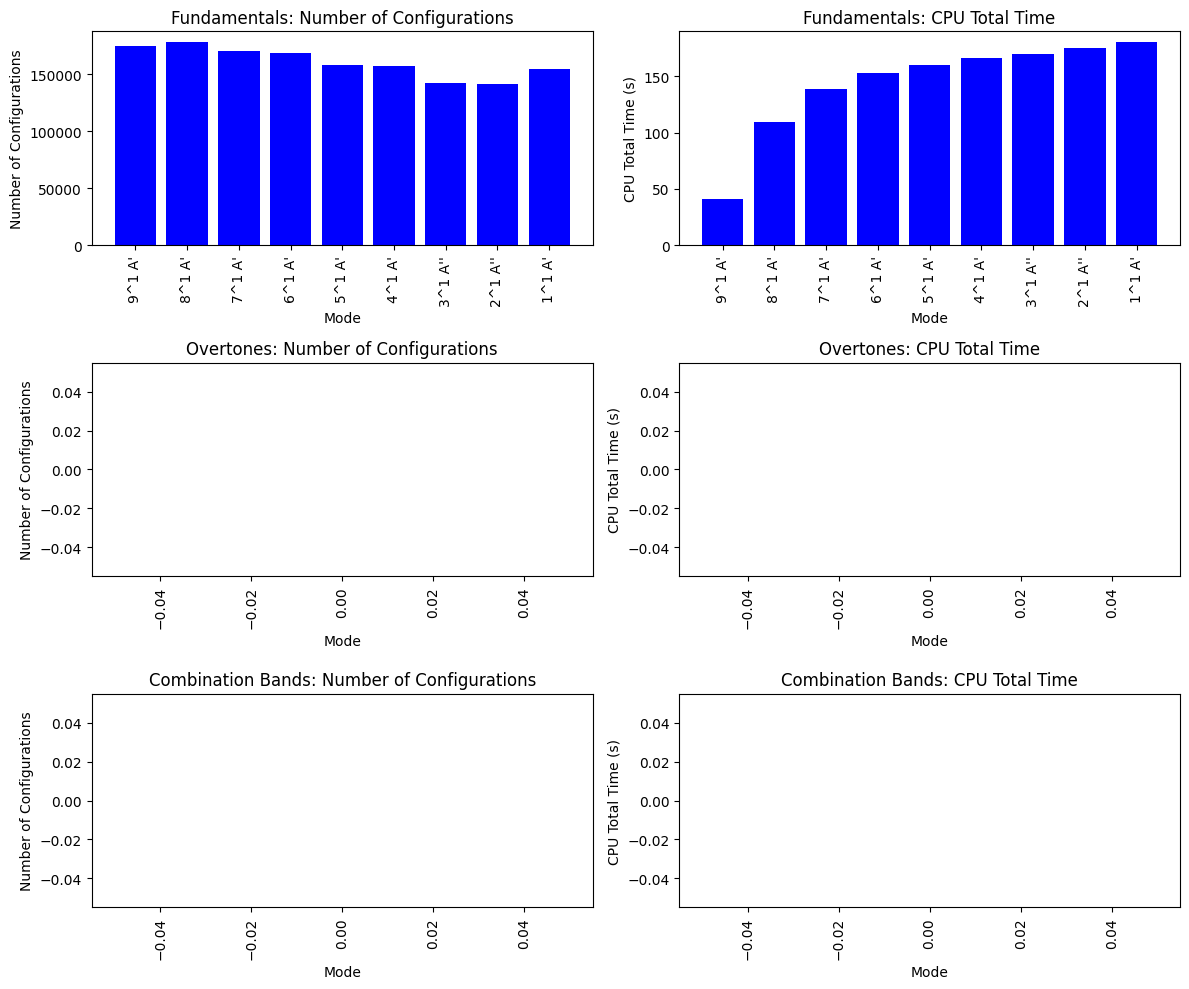

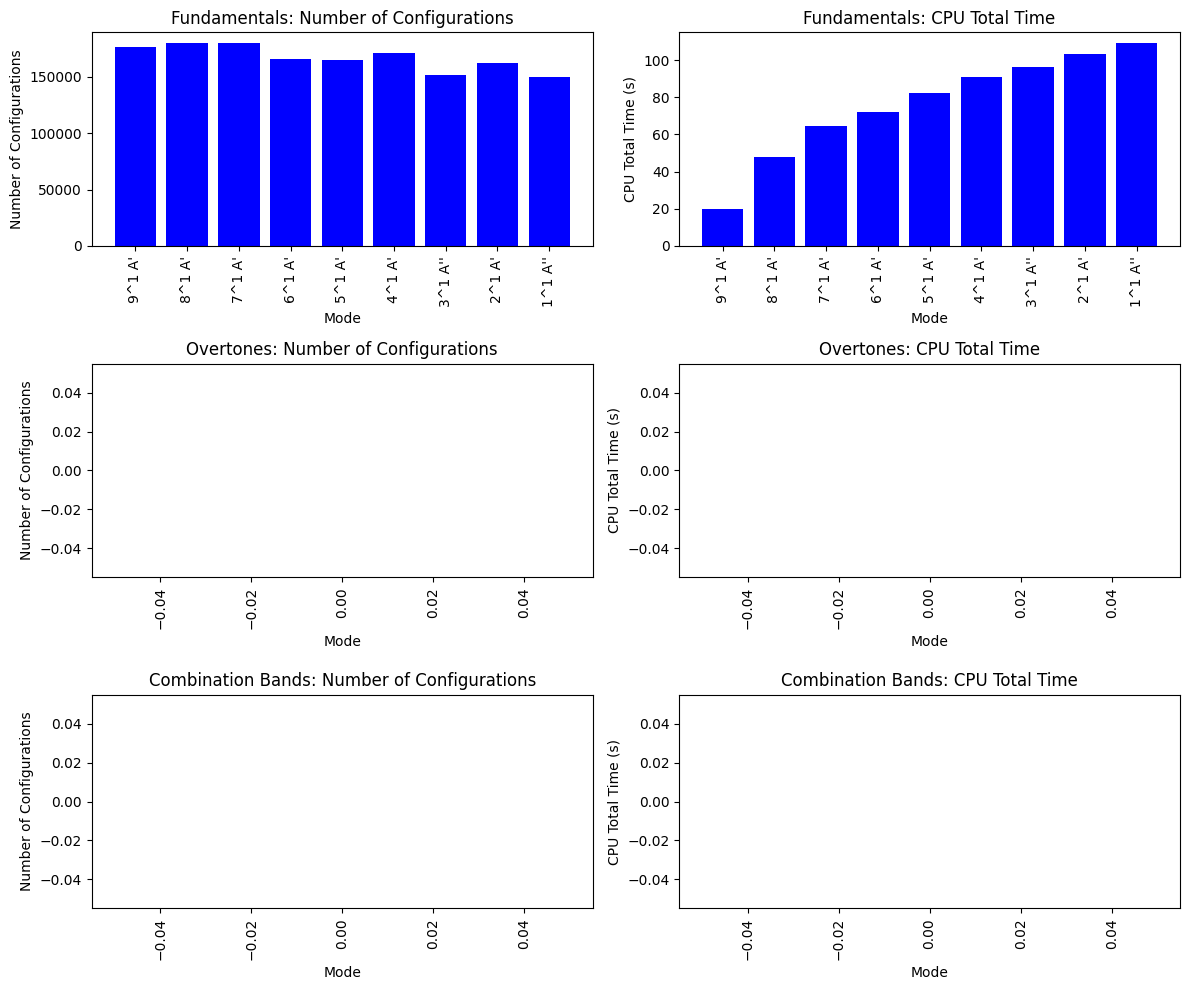

In [183]:
plot_configurations_and_runtime(results_hcooh)
plot_configurations_and_runtime(results_hcood)
plot_configurations_and_runtime(results_dcooh)
plot_configurations_and_runtime(results_dcood)

## Comparison Function for Deuterated Species:

Goal for this is to quickly import multiple files for example deuterated species and compare the difference in wavenumbers

In [184]:
dcood_path = "/home/lme/formic_acid_dennis/monomer_calculations/dcood.out"
dcooh_path = "/home/lme/formic_acid_dennis/monomer_calculations/dcooh/dcooh.out" 
hcood_path =  "/home/lme/formic_acid_dennis/monomer_calculations/hcood/hcood.out"
hcooh_path =  "/home/lme/formic_acid_dennis/monomer_calculations/hcooh/hcooh.out"

labels = ["DCOOD", "DCOOH", "HCOOD", "HCOOH"]
filepaths = [dcood_path, dcooh_path, hcood_path, hcooh_path]

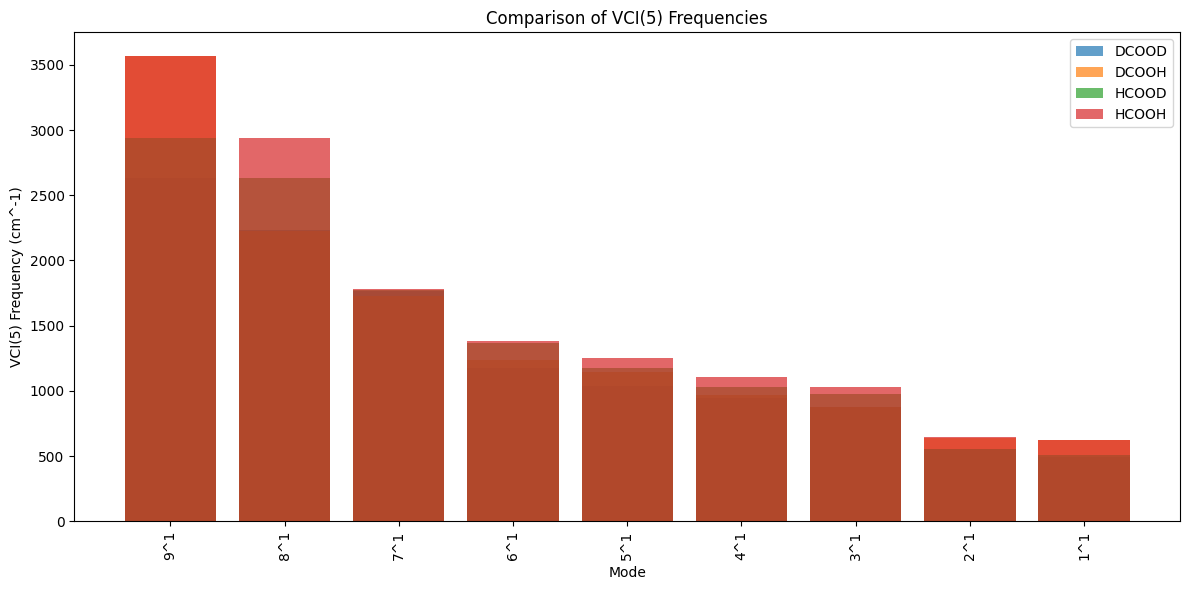

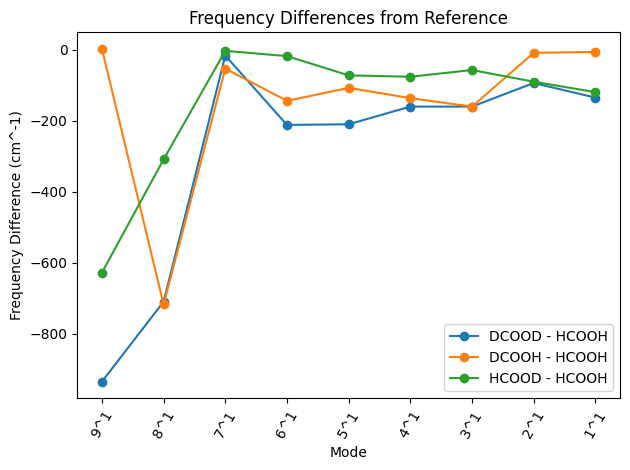

In [185]:
def compare_all_fundamentals(filepaths, labels = None, reference=None, plot_diff=False, strip_irrep = False):
    # Extract all results
    
    total_results = {}
    for idx, file_path in enumerate(filepaths):
        results = parse_molpro_vci_results(file_path)
        if labels is not None:
            total_results[labels[idx]] = results["fundamentals"]
                    
        else:
            total_results[f"File {idx+1}"] = results["fundamentals"]
    # Extract all fundamentals
    fundamentals_list = []
    for key, result in total_results.items():
        label = key
        mode = result['Mode']        
        if strip_irrep:
            mode = [m.split()[0] for m in mode]

        vci_freq  = result['VCI(5)'].astype(float)
        
        # Append the results to the list
        fundamentals_list.append(pd.DataFrame({
            "label": label,
            'Mode': mode,
            'VCI(5)': vci_freq
        }))
    
    
    fundamentals_df = pd.concat(fundamentals_list, ignore_index=True)
    plt.figure(figsize=(12, 6))
    for label in fundamentals_df['label'].unique():
        subset = fundamentals_df[fundamentals_df['label'] == label]
        plt.bar(subset['Mode'], subset['VCI(5)'], label=label, alpha=0.7)
    plt.xlabel('Mode')
    plt.ylabel('VCI(5) Frequency (cm^-1)')
    plt.title('Comparison of VCI(5) Frequencies')
    plt.xticks(rotation=90)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    if plot_diff:
        if reference is None:
            raise ValueError("Reference Label must be provided for difference plotting.")
        
        reference_freqs = fundamentals_df[fundamentals_df['label'] == reference]['VCI(5)'].values
        # Calculate differences
        for label in fundamentals_df['label'].unique():
            if label == reference:
                continue
            subset = fundamentals_df[fundamentals_df['label'] == label]
            diff_freqs = subset['VCI(5)'].values - reference_freqs
            plt.plot(subset['Mode'], diff_freqs, marker='o', label=f"{label} - {reference}")
    plt.xlabel('Mode')
    plt.ylabel('Frequency Difference (cm^-1)')
    plt.title('Frequency Differences from Reference')
    plt.xticks(rotation=60)
    plt.legend()
    plt.tight_layout()
    plt.show()
compare_all_fundamentals(filepaths, labels=labels, reference="HCOOH", plot_diff=True, strip_irrep=True)

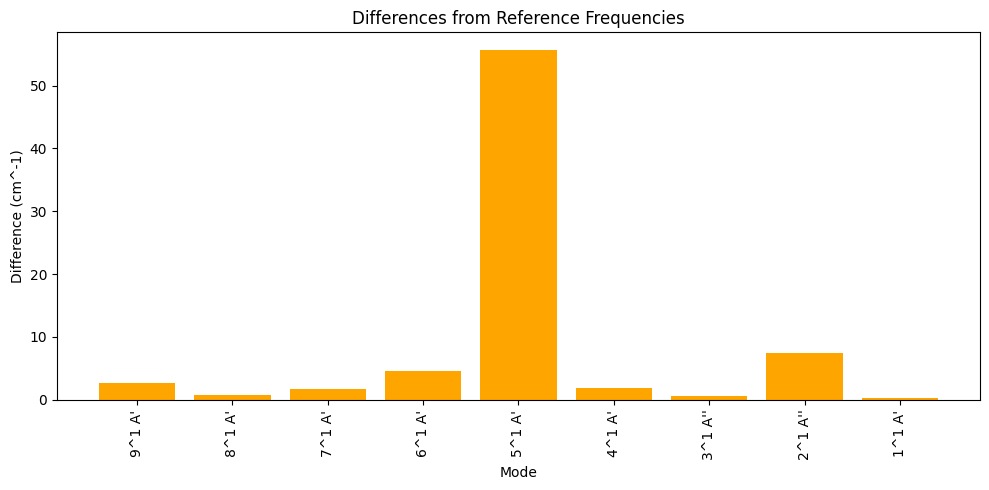

--------------Differences for HCOOH gas phase:-------------------
      Mode  Difference
0   9^1 A'        2.66
1   8^1 A'        0.73
2   7^1 A'        1.65
3   6^1 A'        4.60
4   5^1 A'       55.68
5   4^1 A'        1.85
6  3^1 A''        0.69
7  2^1 A''        7.39
8   1^1 A'        0.36


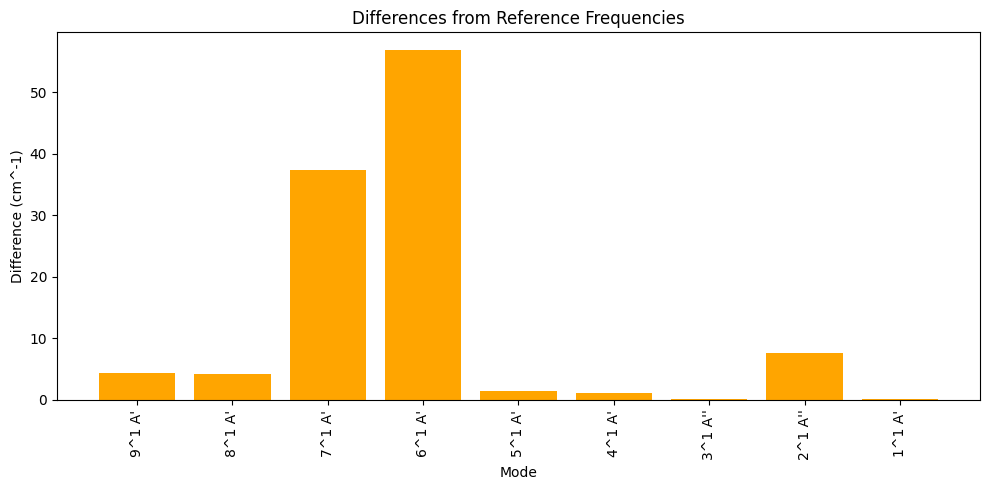

--------------Differences for DCOOH gas phase:-------------------
      Mode  Difference
0   9^1 A'        4.34
1   8^1 A'        4.15
2   7^1 A'       37.36
3   6^1 A'       56.88
4   5^1 A'        1.42
5   4^1 A'        1.19
6  3^1 A''        0.20
7  2^1 A''        7.67
8   1^1 A'        0.17


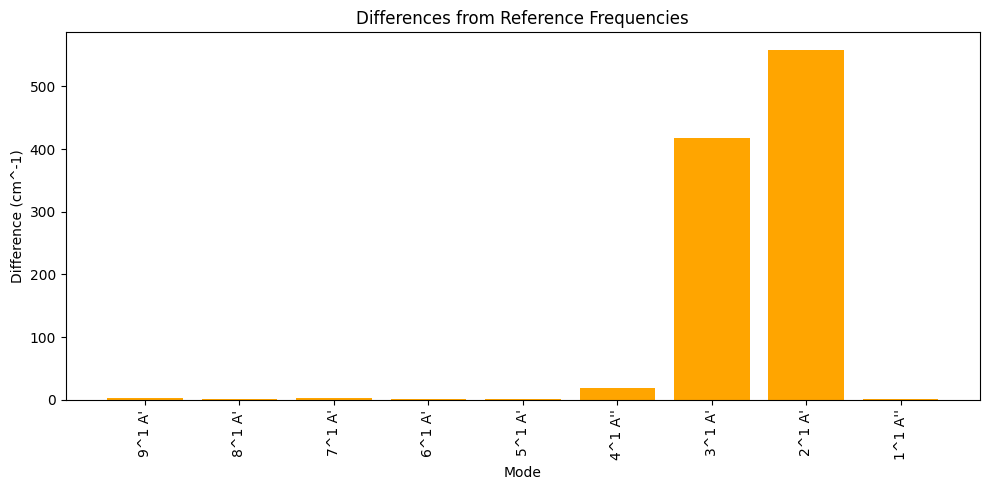

--------------Differences for HCOOD gas phase:-------------------
      Mode  Difference
0   9^1 A'        2.36
1   8^1 A'        1.31
2   7^1 A'        3.51
3   6^1 A'        0.38
4   5^1 A'        1.56
5  4^1 A''       19.27
6   3^1 A'      417.70
7   2^1 A'      558.38
8  1^1 A''        0.61


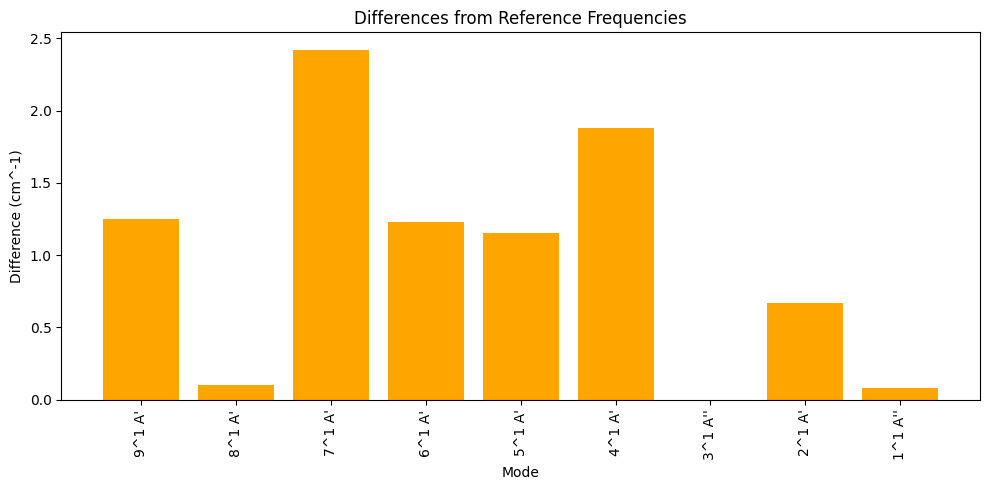

--------------Differences for DCOOD gas phase:-------------------
      Mode  Difference
0   9^1 A'        1.25
1   8^1 A'        0.10
2   7^1 A'        2.42
3   6^1 A'        1.23
4   5^1 A'        1.15
5   4^1 A'        1.88
6  3^1 A''        0.00
7   2^1 A'        0.67
8  1^1 A''        0.08


In [194]:
def compare_with_reference(fundamentals_df, reference_dict, plot_differences=True):
    """ 
    Can be used to compare the VCI(5) frequencies with a reference dictionary.
    """
    vci_freq = fundamentals_df['VCI(5)'].astype(float)
    modes = fundamentals_df['Mode']
    differences = []
    for idx, value in enumerate(reference_dict.values()):
        difference = np.abs(vci_freq[idx] - value)
        differences.append(difference)
    
    # Make a Dataframe with modes and differences
    diff_df = pd.DataFrame({
        'Mode': modes,
        'Difference': differences
    })

    if plot_differences:
        plt.figure(figsize=(10, 5))
        plt.bar(diff_df['Mode'], diff_df['Difference'], color='orange')
        plt.xlabel('Mode')
        plt.ylabel('Difference (cm^-1)')
        plt.title('Differences from Reference Frequencies')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
    
    return diff_df
    

fundamentals_hcooh = results_hcooh["fundamentals"]
fundamentals_dcooh = results_dcooh["fundamentals"]
fundamentals_hcood = results_hcood["fundamentals"]
fundamentals_dcood = results_dcood["fundamentals"]
diff_hcooh_gas =  compare_with_reference(fundamentals_hcooh, trans_hcooh_gas, plot_differences=True)
print("--------------Differences for HCOOH gas phase:-------------------")
print(diff_hcooh_gas)
diff_dcooh_gas =  compare_with_reference(fundamentals_dcooh, trans_dcooh_gas, plot_differences=True)
print("--------------Differences for DCOOH gas phase:-------------------")
print(diff_dcooh_gas)
diff_hcood_gas =  compare_with_reference(fundamentals_hcood, trans_hcood_gas, plot_differences=True)
print("--------------Differences for HCOOD gas phase:-------------------")
print(diff_hcood_gas)
diff_dcood_gas =  compare_with_reference(fundamentals_dcood, trans_dcood_gas, plot_differences=True)
print("--------------Differences for DCOOD gas phase:-------------------")
print(diff_dcood_gas)


0    -2.66
1    -0.73
2     1.65
3     4.60
4   -55.68
5     1.85
6    -0.69
7     7.39
8     0.36
Name: VCI(5), dtype: float64


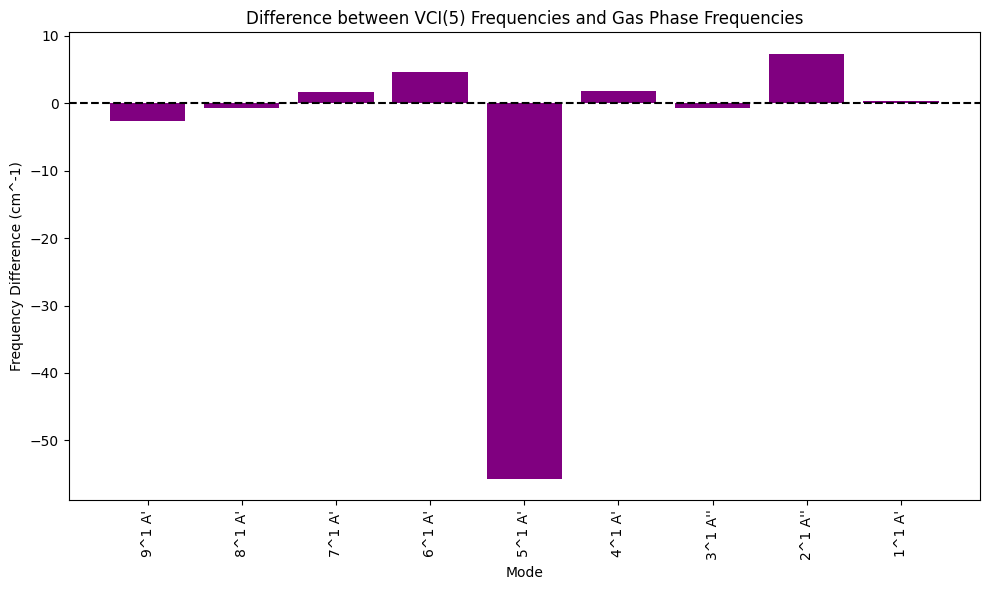

In [187]:
fundamentals_hcooh = results_hcooh["fundamentals"]["VCI(5)"].astype(float)
gas_frequencies = [value for value in trans_hcooh_gas.values()]

# Calulate the difference
diff_frequencies = fundamentals_hcooh - np.array(gas_frequencies)

labels = results_hcooh["fundamentals"]["Mode"].values

print(diff_frequencies)

plt.figure(figsize=(10, 6))
plt.bar(labels, diff_frequencies, color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.title('Difference between VCI(5) Frequencies and Gas Phase Frequencies')
plt.xlabel('Mode')
plt.ylabel('Frequency Difference (cm^-1)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



Note that v5 is is a multistate, but still we have a deviation of about 25 cm⁻1

In [188]:
old_differences = {
    "v1": 8.5,
    "v2": 3.2,
    "v3": 5.9,
    "v4": 6.0,
    "v5": 25.7,
    "v6": -0.2,
    "v7": 2.7,
    "v8": 7.6,
    "v9": 0.7
}

old_differences_pd = pd.DataFrame.from_dict(old_differences, orient='index', columns=['Difference'])
print(old_differences_pd)
print(diff_frequencies)

    Difference
v1         8.5
v2         3.2
v3         5.9
v4         6.0
v5        25.7
v6        -0.2
v7         2.7
v8         7.6
v9         0.7
0    -2.66
1    -0.73
2     1.65
3     4.60
4   -55.68
5     1.85
6    -0.69
7     7.39
8     0.36
Name: VCI(5), dtype: float64
